In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
directory = ''
BA_file = directory+'fig_3_fire_burned_area.csv'
BA = pd.read_csv(BA_file)

SmokePM_file = directory+'fig_5_cz_wui_pm.csv'
SmokePM = pd.read_csv(SmokePM_file)

WUI_file = directory+'fig_s3_burned_area_summary.csv'
WUI = pd.read_csv(WUI_file)

AQS_file = directory+'AQS_ts.csv'
AQS = pd.read_csv(AQS_file, parse_dates=["Date"])

IMPROVE_file = directory+'improve_ts.csv'
IMPROVE = pd.read_csv(IMPROVE_file, parse_dates=["Date"])

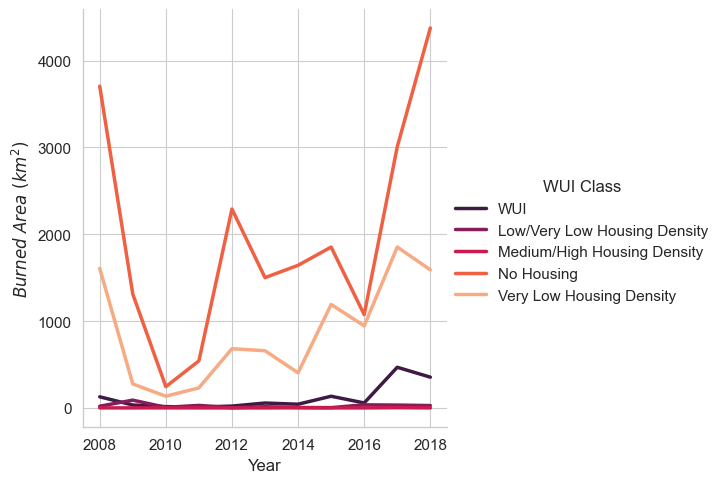

In [6]:
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 2.5})
ax = sns.relplot(
    data=BA, kind="line",
    x="Year", y="Burned area (km2)", hue="WUI Class",palette="rocket",
)

labels = '$Burned~Area~(km^2)$'
ax.set_ylabels(labels)
fig = ax.fig
fig.savefig(directory+'Fig3_final.png')  

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cz/1mn8cjk575dg383t5tlm7m3r0000gr/T/ipykernel_7147/2035190837.py:3: SyntaxWarning: invalid escape sequence '\m'
  labels = '$Smoke~PM_{2.5}~(\mu g~/~m^3)$'


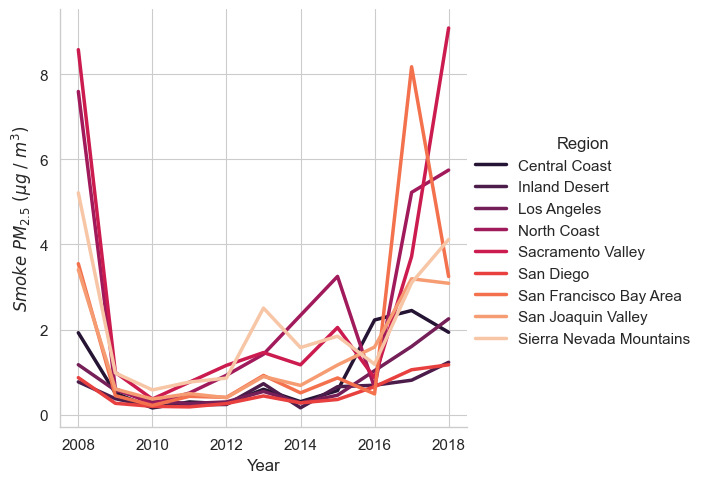

In [7]:
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 2.5})
labels = '$Smoke~PM_{2.5}~(\mu g~/~m^3)$'
ax = sns.relplot(
    data=SmokePM, kind="line", 
    x="Year", y="Smoke PM2.5", hue="Region",palette="rocket",
)
#sns.move_legend(ax, "upper center")
ax.set_ylabels(labels)
fig = ax.fig
fig.savefig(directory+'Fig5_final.png')  

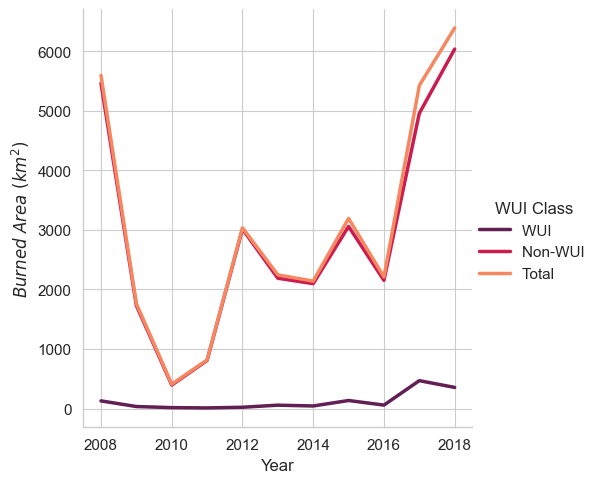

In [8]:
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 2.5})
ax = sns.relplot(
    data=WUI, kind="line", 
    x="Year", y="Burned Area (km2)", hue="WUI Class",palette="rocket",
)
#sns.move_legend(ax, "upper center")
labels = '$Burned~Area~(km^2)$'
ax.set_ylabels(labels)
fig = ax.fig
fig.savefig(directory+'FigS3_final.png')  

(0.0, 50.0)

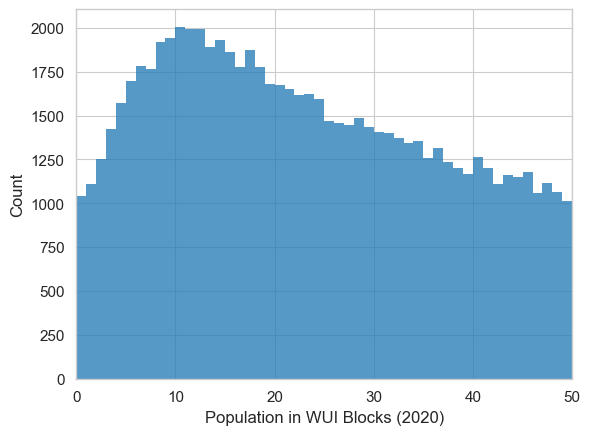

In [9]:
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 2.5})
pop_file = directory+'wui_only.csv'
pop = pd.read_csv(pop_file)

ax=sns.histplot(data=pop, x="POP2020", binwidth=1)
ax.set(xlabel='Population in WUI Blocks (2020)', ylabel='Count')

plt.xlim(0, 50)

In [10]:
monthly = IMPROVE.set_index('Date').resample('M').mean() 
monthly = monthly.reset_index()
monthly['Date'] = pd.to_datetime(monthly['Date'])
print(monthly)

monthlyAQS = AQS.set_index('Date').resample('M').mean() 
monthlyAQS = monthlyAQS.reset_index()
monthlyAQS['Date'] = pd.to_datetime(monthlyAQS['Date'])
print(monthlyAQS)

/var/folders/cz/1mn8cjk575dg383t5tlm7m3r0000gr/T/ipykernel_7147/3697153808.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  AQS = pd.read_csv(AQS_file, parse_dates=["Date"])


          Date  CMAQ All-Source  CMAQ No-Fire    IMPROVE
0   2008-01-31         7.235657      7.210373   5.343121
1   2008-02-29         9.173588      9.110289   7.171969
2   2008-03-31         9.547045      9.513139   8.230063
3   2008-04-30         9.497752      9.355824   9.306652
4   2008-05-31         9.471093      9.111287   9.140955
..         ...              ...           ...        ...
127 2018-08-31        17.293026      6.623695  21.163430
128 2018-09-30        12.057925      6.878316   8.495669
129 2018-10-31         9.080050      6.105754   6.920560
130 2018-11-30        10.972003      7.616469  13.711295
131 2018-12-31         8.471749      7.212945   9.036865

[132 rows x 4 columns]
          Date  CMAQ All-Source  CMAQ No-Fire        AQS
0   2008-01-31        12.415032     12.360504  12.557209
1   2008-02-29        14.836520     14.784291  13.435738
2   2008-03-31        13.430128     13.378070  10.078349
3   2008-04-30        12.576606     12.434515  10.022113
4   200

/var/folders/cz/1mn8cjk575dg383t5tlm7m3r0000gr/T/ipykernel_7147/3697153808.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  IMPROVE = pd.read_csv(IMPROVE_file, parse_dates=["Date"])
/var/folders/cz/1mn8cjk575dg383t5tlm7m3r0000gr/T/ipykernel_7147/3697153808.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = IMPROVE.set_index('Date').resample('M').mean()
/var/folders/cz/1mn8cjk575dg383t5tlm7m3r0000gr/T/ipykernel_7147/3697153808.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthlyAQS = AQS.set_index('Date').resample('M').mean()


In [11]:
df_long = pd.melt(monthly,
                  id_vars=['Date'],  # Columns to keep as identifier variables
                  value_vars=['IMPROVE','CMAQ All-Source', 'CMAQ No-Fire'],  # Columns to unpivot
                  var_name='Source',  # Name for the new column holding the original column names
                  value_name='PM2.5',
                  ignore_index=True)  # Name for the new column holding the values
#df_long=df_long.set_index('Date')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) # Optional: Adjust display width for better readability

df_long

,Date,Source,PM2.5
0,2008-01-31,IMPROVE,5.343121
1,2008-02-29,IMPROVE,7.171969
2,2008-03-31,IMPROVE,8.230063
3,2008-04-30,IMPROVE,9.306652
4,2008-05-31,IMPROVE,9.140955
5,2008-06-30,IMPROVE,14.485785
6,2008-07-31,IMPROVE,17.567728
7,2008-08-31,IMPROVE,8.119592
8,2008-09-30,IMPROVE,9.398222
9,2008-10-31,IMPROVE,7.661468


In [12]:
df_longAQS = pd.melt(monthlyAQS,
                  id_vars=['Date'],  # Columns to keep as identifier variables
                  value_vars=['AQS','CMAQ All-Source', 'CMAQ No-Fire'],  # Columns to unpivot
                  var_name='Source',  # Name for the new column holding the original column names
                  value_name='PM2.5',
                  ignore_index=True)  # Name for the new column holding the values

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) # Optional: Adjust display width for better readability

df_longAQS

,Date,Source,PM2.5
0,2008-01-31,AQS,12.557209
1,2008-02-29,AQS,13.435738
2,2008-03-31,AQS,10.078349
3,2008-04-30,AQS,10.022113
4,2008-05-31,AQS,11.034434
5,2008-06-30,AQS,18.525570
6,2008-07-31,AQS,20.287087
7,2008-08-31,AQS,10.874872
8,2008-09-30,AQS,12.193407
9,2008-10-31,AQS,12.233521


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cz/1mn8cjk575dg383t5tlm7m3r0000gr/T/ipykernel_7147/660462149.py:12: SyntaxWarning: invalid escape sequence '\m'
  labels = '$PM_{2.5}~(\mu g~/~m^3)$'


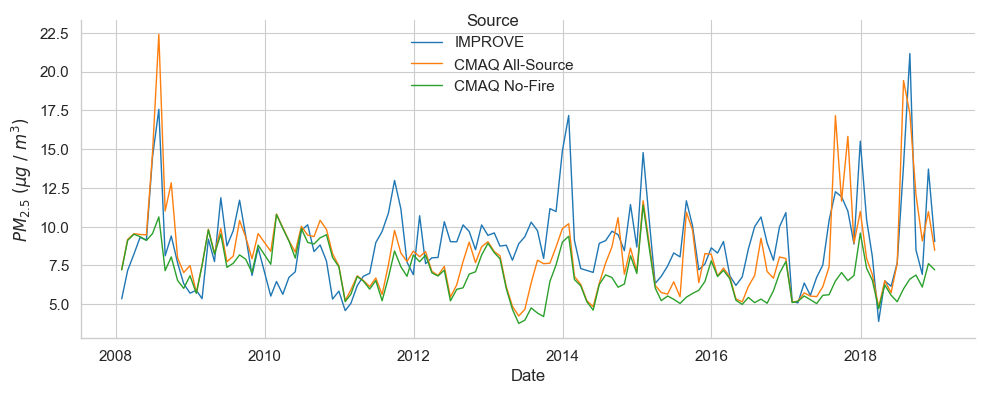

In [13]:
sns.color_palette("colorblind")
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 1})
#fig, ax = plt.subplots(figsize=(10, 6)) 
ax = sns.relplot(
    data=df_long, kind="line",
    x="Date", y="PM2.5", hue="Source",#palette="rocket",
    height=4,aspect=2.5
)
sns.move_legend(ax, "upper center")

labels = '$PM_{2.5}~(\mu g~/~m^3)$'
ax.set_ylabels(labels)
fig = ax.fig
fig.savefig(directory+'IMPROVE_final.png')  

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/cz/1mn8cjk575dg383t5tlm7m3r0000gr/T/ipykernel_7147/1177001587.py:11: SyntaxWarning: invalid escape sequence '\m'
  labels = '$PM_{2.5}~(\mu g~/~m^3)$'


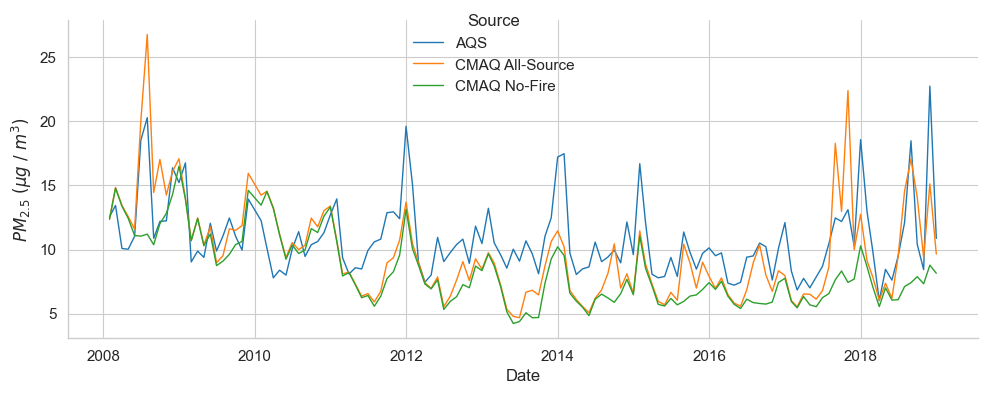

In [14]:
sns.color_palette("colorblind")
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 1})
ax = sns.relplot(
    data=df_longAQS, kind="line",
    x="Date", y="PM2.5", hue="Source",#palette="rocket",
    height=4,aspect=2.5
)
sns.move_legend(ax, "upper center")
#plt.show()
labels = '$PM_{2.5}~(\mu g~/~m^3)$'
ax.set_ylabels(labels)
fig = ax.fig
fig.savefig(directory+'AQS_final.png')  